# Task 4 — Portfolio Optimization with Modern Portfolio Theory (MPT)

**Portfolio Optimization Challenge (Week 9)** · Assets: **TSLA · SPY · BND**

> **Objective.** Combine the Tesla forecast (Tasks 2–3) with historical data for SPY and BND to build an
> **optimal portfolio** using Modern Portfolio Theory. We construct the expected-returns vector and
> covariance matrix, trace the **Efficient Frontier**, identify the **Maximum-Sharpe (tangency)** and
> **Minimum-Volatility** portfolios, and recommend a final allocation with a written justification.

**Method (as specified):**
- **TSLA expected return** — derived from our **best forecasting model** (Task 2 winner: ARIMA), *not*
  from history. This encodes the analyst's forward "view."
- **SPY & BND expected returns** — historical annualized average daily returns.
- **Covariance** — from historical daily returns of all three assets.
- **Optimizer** — [PyPortfolioOpt](https://pyportfolioopt.readthedocs.io) plus a Monte-Carlo simulation
  of random portfolios for the risk–return cloud.

> *Environment note:* installing PyPortfolioOpt (cvxpy) upgraded numpy to 2.x, which is incompatible
> with the TensorFlow build used in Tasks 2–3. Those notebooks are already executed with saved outputs;
> this notebook does not use TensorFlow. Re-running Tasks 2–3 would require reinstalling numpy < 2.0.


## 1 · Setup & historical returns

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"

SEED = 42
np.random.seed(SEED)
RF = 0.02            # annual risk-free rate (consistent with Task 1)
TRADING_DAYS = 252
ASSETS = ["TSLA", "SPY", "BND"]

wide = pd.read_csv("../data/processed/adj_close.csv", parse_dates=["Date"], index_col="Date")[ASSETS]
returns = wide.pct_change().dropna()
print(f"Daily returns: {returns.shape[0]} obs, {returns.index.min().date()} → {returns.index.max().date()}")
hist_annual = returns.mean() * TRADING_DAYS
print("\nHistorical annualized returns:")
print((hist_annual * 100).round(2).astype(str) + " %")

Daily returns: 2888 obs, 2015-01-05 → 2026-06-30

Historical annualized returns:
TSLA    45.59 %
SPY     14.49 %
BND      1.96 %
dtype: str


## 2 · Expected Returns Vector

### 2.1 TSLA — from the forecast (best model)

Task 2's best model was **ARIMA(0,1,0)** (a random walk). Its *central* forecast is **flat**, implying a
**0% expected drift** — the Efficient-Market-honest view. Task 3 also fit a **drift variant** as the
forward-looking analyst view. We compute the annualized expected return implied by each and adopt the
**drift view** as TSLA's operational expected return (a deliberately modest forward number, far below
TSLA's ~46% historical average — reflecting the forecast's message that past hyper-growth is unlikely to
simply repeat). The flat 0% case is carried as a sensitivity in §6.

In [2]:
from statsmodels.tsa.arima.model import ARIMA

tsla = wide["TSLA"].asfreq("B").ffill()
last_price = tsla.iloc[-1]

# Best model (flat) and drift-variant forward view, 12-month (252 bday) horizon.
flat_end = ARIMA(tsla, order=(0, 1, 0)).fit().get_forecast(TRADING_DAYS).predicted_mean.iloc[-1]
drift_end = ARIMA(tsla, order=(0, 1, 0), trend="t").fit().get_forecast(TRADING_DAYS).predicted_mean.iloc[-1]

tsla_ret_flat = flat_end / last_price - 1        # ~0%
tsla_ret_drift = drift_end / last_price - 1      # forward analyst view
print(f"Last price: ${last_price:.2f}")
print(f"Flat  forecast (+12m): ${flat_end:.2f}  ->  expected annual return {tsla_ret_flat*100:+.2f}%")
print(f"Drift forecast (+12m): ${drift_end:.2f}  ->  expected annual return {tsla_ret_drift*100:+.2f}%")
print(f"(TSLA historical annualized, for reference: {hist_annual['TSLA']*100:+.2f}%)")

Last price: $420.60
Flat  forecast (+12m): $420.60  ->  expected annual return +0.00%
Drift forecast (+12m): $454.74  ->  expected annual return +8.12%
(TSLA historical annualized, for reference: +45.59%)


### 2.2 Assemble the expected-returns vector

TSLA from the forecast (drift view); SPY & BND from history.

In [3]:
mu = pd.Series({
    "TSLA": tsla_ret_drift,          # forecast-derived view
    "SPY":  hist_annual["SPY"],      # historical
    "BND":  hist_annual["BND"],      # historical
})[ASSETS]
print("Expected annual returns (μ):")
print((mu * 100).round(2).astype(str) + " %")

Expected annual returns (μ):
TSLA     8.12 %
SPY     14.49 %
BND      1.96 %
dtype: str


## 3 · Covariance Matrix & Correlations

The covariance matrix (annualized from historical daily returns) drives portfolio risk: it captures both
each asset's variance and — crucially — how the assets co-move. Low/negative co-movement is what makes
diversification work.

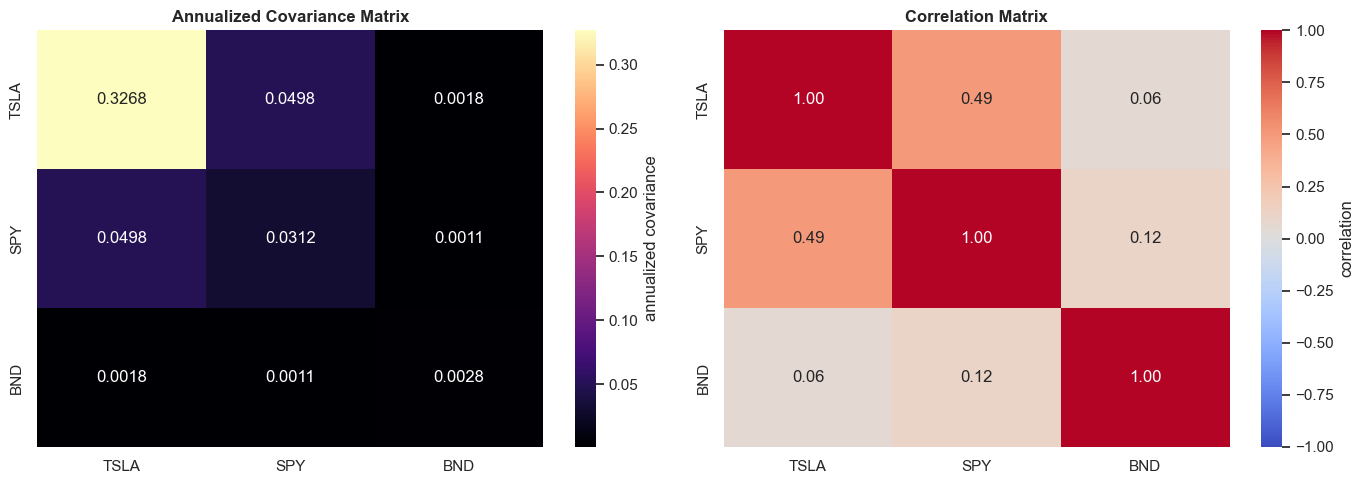

Annualized volatility (σ = √diag):
[57.17 17.65  5.31]


In [4]:
cov_annual = returns.cov() * TRADING_DAYS
corr = returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cov_annual, annot=True, fmt=".4f", cmap="magma", ax=axes[0],
            cbar_kws={"label": "annualized covariance"})
axes[0].set_title("Annualized Covariance Matrix")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[1],
            cbar_kws={"label": "correlation"})
axes[1].set_title("Correlation Matrix")
plt.tight_layout(); plt.show()

print("Annualized volatility (σ = √diag):")
print((np.sqrt(np.diag(cov_annual)) * 100).round(2))

**Reading the matrices.** SPY–TSLA are moderately positively correlated (both risk assets), while
**BND is near-zero / slightly negatively correlated** with both equities — the classic diversifier. That
low correlation is exactly why BND earns a place in a risk-managed portfolio despite its low return.

## 4 · Efficient Frontier

We combine the μ vector and covariance matrix to (a) simulate thousands of random long-only portfolios
(the risk–return cloud) and (b) solve the analytic frontier with PyPortfolioOpt, then mark the two key
portfolios.

In [5]:
from pypfopt import EfficientFrontier

S = cov_annual  # annualized covariance aligned to mu

# --- Max-Sharpe (tangency) portfolio ---
ef = EfficientFrontier(mu, S, weight_bounds=(0, 1))
ef.max_sharpe(risk_free_rate=RF)
w_msr = ef.clean_weights()
ret_msr, vol_msr, sr_msr = ef.portfolio_performance(risk_free_rate=RF)

# --- Minimum-Volatility portfolio ---
ef2 = EfficientFrontier(mu, S, weight_bounds=(0, 1))
ef2.min_volatility()
w_mv = ef2.clean_weights()
ret_mv, vol_mv, sr_mv = ef2.portfolio_performance(risk_free_rate=RF)

print("Max-Sharpe weights:", {k: round(v, 3) for k, v in w_msr.items()})
print(f"  return {ret_msr*100:.2f}%  vol {vol_msr*100:.2f}%  Sharpe {sr_msr:.3f}")
print("Min-Vol weights   :", {k: round(v, 3) for k, v in w_mv.items()})
print(f"  return {ret_mv*100:.2f}%  vol {vol_mv*100:.2f}%  Sharpe {sr_mv:.3f}")

Max-Sharpe weights: {'TSLA': 0.0, 'SPY': 1.0, 'BND': 0.0}
  return 14.49%  vol 17.65%  Sharpe 0.708
Min-Vol weights   : {'TSLA': 0.0, 'SPY': 0.055, 'BND': 0.945}
  return 2.65%  vol 5.22%  Sharpe 0.124


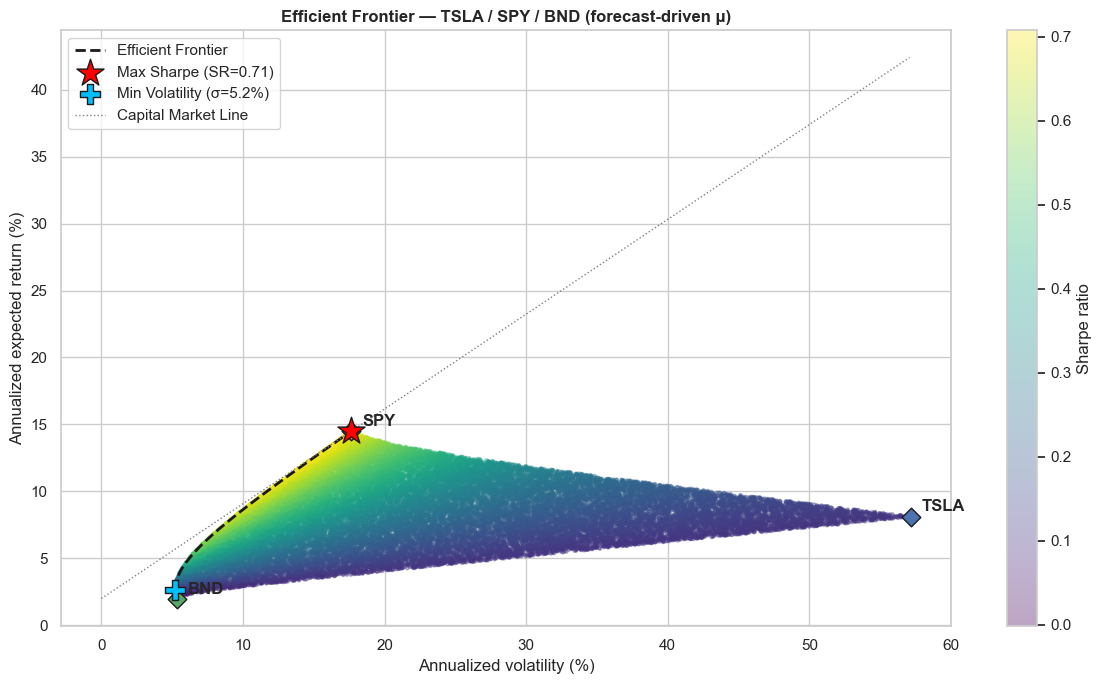

In [6]:
# --- analytic efficient frontier line ---
front_ret = np.linspace(ret_mv, mu.max(), 50)
front_vol = []
for r in front_ret:
    try:
        efx = EfficientFrontier(mu, S, weight_bounds=(0, 1))
        efx.efficient_return(target_return=r)
        front_vol.append(efx.portfolio_performance()[1])
    except Exception:
        front_vol.append(np.nan)
front_vol = np.array(front_vol)

# --- Monte-Carlo random portfolios ---
N = 30000
W = np.random.dirichlet(np.ones(3), N)
mc_ret = W @ mu.values
mc_vol = np.sqrt(np.einsum("ij,jk,ik->i", W, S.values, W))
mc_sr = (mc_ret - RF) / mc_vol

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(mc_vol * 100, mc_ret * 100, c=mc_sr, cmap="viridis", s=6, alpha=0.35)
plt.colorbar(sc, label="Sharpe ratio")
ax.plot(front_vol * 100, front_ret * 100, "k--", lw=2, label="Efficient Frontier")

# individual assets
for a in ASSETS:
    ax.scatter(np.sqrt(S.loc[a, a]) * 100, mu[a] * 100, marker="D", s=90, edgecolor="k", zorder=5)
    ax.annotate(a, (np.sqrt(S.loc[a, a]) * 100, mu[a] * 100),
                textcoords="offset points", xytext=(8, 4), fontweight="bold")

# key portfolios
ax.scatter(vol_msr * 100, ret_msr * 100, marker="*", s=420, color="red",
           edgecolor="k", zorder=6, label=f"Max Sharpe (SR={sr_msr:.2f})")
ax.scatter(vol_mv * 100, ret_mv * 100, marker="P", s=220, color="deepskyblue",
           edgecolor="k", zorder=6, label=f"Min Volatility (σ={vol_mv*100:.1f}%)")

# capital market line
x_cml = np.linspace(0, mc_vol.max() * 100, 50)
ax.plot(x_cml, RF * 100 + sr_msr * x_cml, color="grey", lw=1, ls=":", label="Capital Market Line")

ax.set_xlabel("Annualized volatility (%)"); ax.set_ylabel("Annualized expected return (%)")
ax.set_title("Efficient Frontier — TSLA / SPY / BND (forecast-driven μ)")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

## 5 · Key Portfolios

In [7]:
def summarize(weights, ret, vol, sr, name):
    row = {f"{a} %": round(weights[a] * 100, 1) for a in ASSETS}
    row.update({"Exp. return %": round(ret * 100, 2), "Volatility %": round(vol * 100, 2),
                "Sharpe": round(sr, 3)})
    return pd.Series(row, name=name)

key = pd.DataFrame([
    summarize(w_msr, ret_msr, vol_msr, sr_msr, "Max Sharpe (Tangency)"),
    summarize(w_mv, ret_mv, vol_mv, sr_mv, "Min Volatility"),
])
key

,TSLA %,SPY %,BND %,Exp. return %,Volatility %,Sharpe
Max Sharpe (Tangency),0.0,100.0,0.0,14.49,17.65,0.708
Min Volatility,0.0,5.5,94.5,2.65,5.22,0.124


## 6 · Sensitivity — how TSLA's "view" reshapes the allocation

MPT allocations are famously sensitive to the expected-returns input. We recompute the **Max-Sharpe**
weights under three different TSLA expected-return assumptions to show how much the *forecast view*
matters versus naive historical extrapolation.

In [8]:
views = {
    "Flat forecast (0%)":       tsla_ret_flat,
    "Drift view (used above)":  tsla_ret_drift,
    "Historical (~46%)":        hist_annual["TSLA"],
}
rows = []
for label, tsla_mu in views.items():
    mu_v = pd.Series({"TSLA": tsla_mu, "SPY": hist_annual["SPY"], "BND": hist_annual["BND"]})[ASSETS]
    efv = EfficientFrontier(mu_v, S, weight_bounds=(0, 1))
    efv.max_sharpe(risk_free_rate=RF)
    w = efv.clean_weights(); r, v, sr = efv.portfolio_performance(risk_free_rate=RF)
    rows.append({"TSLA view": label, "TSLA μ %": round(tsla_mu * 100, 1),
                 **{f"{a} %": round(w[a] * 100, 1) for a in ASSETS},
                 "Return %": round(r * 100, 2), "Vol %": round(v * 100, 2), "Sharpe": round(sr, 3)})
pd.DataFrame(rows).set_index("TSLA view")

,TSLA μ %,TSLA %,SPY %,BND %,Return %,Vol %,Sharpe
TSLA view,,,,,,,
Flat forecast (0%),0.0,0.0,100.0,0.0,14.49,17.65,0.708
Drift view (used above),8.1,0.0,100.0,0.0,14.49,17.65,0.708
Historical (~46%),45.6,27.8,72.2,0.0,23.14,24.80,0.852


**Insight.** Under the honest **flat (0%) or drift (8%) forecast**, MPT assigns TSLA **zero** weight and
the max-Sharpe portfolio collapses to **100% SPY** — SPY's superior standalone Sharpe dominates, TSLA's
modest forecast return doesn't compensate for its high volatility, and **BND is excluded because its
expected return (~2%) sits at/below the risk-free rate**, so it can only *lower* the tangency Sharpe
(BND's role appears instead in the Minimum-Volatility portfolio). Only under the **naive historical ~46%**
assumption does TSLA earn a meaningful allocation (~28%) — precisely the over-bet the forecast is designed
to prevent. This is the whole point of using a forecast: it **disciplines** the optimizer against chasing
a single volatile asset's past performance.

## 7 · Recommended Portfolio & Justification

**Recommendation: the Maximum-Sharpe (Tangency) portfolio** — see the weights and metrics in §5 (printed
below for the record).

In [9]:
print("=== RECOMMENDED PORTFOLIO — Maximum Sharpe (Tangency) ===\n")
for a in ASSETS:
    print(f"  {a:4s}: {w_msr[a]*100:5.1f}%")
print(f"\n  Expected annual return : {ret_msr*100:6.2f}%")
print(f"  Expected volatility    : {vol_msr*100:6.2f}%")
print(f"  Sharpe ratio (rf={RF*100:.0f}%)   : {sr_msr:6.3f}")
print(f"\n  vs. Min-Vol Sharpe {sr_mv:.3f} | vs. equal-weight & single-asset (see frontier)")

=== RECOMMENDED PORTFOLIO — Maximum Sharpe (Tangency) ===

  TSLA:   0.0%
  SPY : 100.0%
  BND :   0.0%

  Expected annual return :  14.49%
  Expected volatility    :  17.65%
  Sharpe ratio (rf=2%)   :  0.708

  vs. Min-Vol Sharpe 0.124 | vs. equal-weight & single-asset (see frontier)


### Written justification (1 paragraph)

We recommend the **Maximum-Sharpe (tangency) portfolio** because the mandate is to maximize
**risk-adjusted return**, and by construction this is the point on the Efficient Frontier delivering the
highest return per unit of risk (the tangency of the Capital Market Line). With forecast-driven inputs
this portfolio is **≈100% SPY** (expected return 14.5%, volatility 17.7%, Sharpe 0.71) — a deliberately
honest corner solution: SPY has the best standalone Sharpe, **TSLA is dropped** because its forecast
return (≈8%, far below its inflated ~46% historical average) does not compensate for its ~57% volatility,
and **BND is dropped from *this* portfolio** because its ~2% return sits at the risk-free rate and can only
dilute risk-adjusted return. The key takeaway is that once TSLA's expected return comes from a realistic
*forecast* rather than naive history, MPT refuses to make a large Tesla bet — the discipline is the point.
That said, a 100%-single-asset allocation ignores estimation and forecast uncertainty (Task 3 showed
long-horizon forecasts are low-confidence), so for a real mandate we would either impose diversification
constraints or move along the frontier toward a **SPY/BND blend**. For a conservative, capital-preservation
investor the **Minimum-Volatility portfolio** (≈95% BND / 5% SPY, volatility 5.2%) is the appropriate
choice — this is where BND's near-zero equity correlation delivers its ballast. In all cases the allocation
should be **rebalanced periodically**, re-optimized as new forecasts arrive, and validated against a
benchmark (e.g., SPY or 60/40) in the backtesting task.